# 08 — GNN link prediction: GCN and R-GCN

First neural graph models in the project. Both run on the same **Compound ∪ Gene ∪ Disease** walk graph nb05 uses and are evaluated on the **locked** split from nb04, so every number here is directly comparable to nb05's Node2Vec results.

The two architectures differ by exactly one choice, which is the point of running them together:

| | GCN (Kipf & Welling 2017) | R-GCN (Schlichtkrull et al. 2018) |
|---|---|---|
| Message passing | one shared weight matrix for all edges | one weight matrix **per relation** |
| Edge types | ignored — `binds` and `associates` are the same edge | ten relations kept distinct |
| Parameters | embedding + 2·d² | embedding + 2·(bases·d²) + relation coefficients |

Everything else is held fixed: same graph, same hub correction, same hidden dimension, same negative sampling, same number of epochs, same seed. The difference in results is therefore attributable to edge-type awareness alone.

Against Node2Vec (nb05) the contrast is different in kind:

| | Node2Vec (nb05) | GNN (here) |
|---|---|---|
| Training | two stages: walks, then Word2Vec | one stage, end to end |
| Uses labels | no — unsupervised | yes — BCE over positive and sampled negative edges |
| Node features | none | learnable `nn.Embedding`, optimised by the link loss |

**Questions this notebook answers**: does end-to-end supervision beat the two-stage pipeline; does edge-type awareness add anything on top of that; and is either worth the extra compute over a random walk.

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, RGCNConv

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART = pathlib.Path("artifacts")
assert ART.exists(), "Run nb4 to the end first - it writes artifacts/."

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Device: {device}")


Device: mps


In [2]:
# --- Locked split (nb4) ---
meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_train, idx_test = split["idx_train"], split["idx_test"]
SEED = int(meta["split_seed"])
y = pairs["y"].to_numpy()
n_pos_test = int(y[idx_test].sum())

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Pairs: {len(pairs):,} | positives: {int(y.sum())} | test positives: {n_pos_test}")


Pairs: 206,312 | positives: 755 | test positives: 151


## 2 · Build the walk graph

The same three preprocessing steps as nb05 and nb07: keep C+G+D, drop the 151 test CtD edges, remove the top-20 gene hubs, restrict to the largest connected component. Edge `kind` is retained here because R-GCN needs it; GCN simply ignores it.

In [3]:
HUB_K = 20
KEEP_KINDS = {"Compound", "Gene", "Disease"}

t0 = time.time()
hetnet = load_hetnet()
print(f"Loaded hetnet in {time.time() - t0:.1f}s")

G = nx.Graph()
for n in hetnet["nodes"]:
    if n["kind"] in KEEP_KINDS:
        G.add_node((n["kind"], n["identifier"]), kind=n["kind"], name=n["name"])
kept = set(G.nodes())
for e in hetnet["edges"]:
    u, v = tuple(e["source_id"]), tuple(e["target_id"])
    if u in kept and v in kept:
        G.add_edge(u, v, kind=e["kind"])

pos_mask  = y == 1
test_mask = np.zeros(len(pairs), dtype=bool); test_mask[idx_test] = True
test_positives  = pairs.loc[pos_mask &  test_mask, ["compound", "disease"]]
train_positives = pairs.loc[pos_mask & ~test_mask, ["compound", "disease"]]

dropped = 0
for c, d in test_positives.itertuples(index=False):
    u, v = ("Compound", c), ("Disease", d)
    if G.has_edge(u, v):
        G.remove_edge(u, v); dropped += 1

gene_deg = sorted(((n, deg) for n, deg in G.degree() if n[0] == "Gene"), key=lambda x: -x[1])
G.remove_nodes_from([n for n, _ in gene_deg[:HUB_K]])
G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print(f"Walk graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges, "
      f"{dropped} test CtD edges dropped")
edge_kinds = pd.Series([d["kind"] for _, _, d in G.edges(data=True)]).value_counts()
print(f"Edge kinds present: {len(edge_kinds)}")
print(edge_kinds.to_string())


Loaded hetnet in 11.5s


Walk graph: 19,683 nodes, 525,174 edges, 151 test CtD edges dropped


Edge kinds present: 10
regulates        245657
interacts        132247
covaries          61504
downregulates     27669
upregulates       26134
associates        12440
binds             11505
resembles          7024
treats              604
palliates           390


## 3 · Tensors

`edge_index` lists every edge in both directions — message passing is directional even on an undirected graph. `edge_type` carries the relation id for the same edge list, and is passed only to R-GCN.

`eval_edges` covers the entire nb04 pair universe so we score all 206,312 pairs in one pass and slice by `idx_test` at evaluation time. Pairs whose endpoints are missing from the graph are pushed to the bottom of the ranking rather than dropped, so the evaluation set stays identical to every other notebook's.

In [4]:
node_list = list(G.nodes())
node_idx  = {n: i for i, n in enumerate(node_list)}
num_nodes = len(node_list)

relation_names = sorted({d["kind"] for _, _, d in G.edges(data=True)})
rel_idx = {k: i for i, k in enumerate(relation_names)}
num_relations = len(relation_names)

src, dst, rel = [], [], []
for u, v, edata in G.edges(data=True):
    r = rel_idx[edata["kind"]]
    src.extend([node_idx[u], node_idx[v]])
    dst.extend([node_idx[v], node_idx[u]])
    rel.extend([r, r])

edge_index = torch.tensor([src, dst], dtype=torch.long).to(device)
edge_type  = torch.tensor(rel, dtype=torch.long).to(device)

print(f"num_nodes {num_nodes:,} | edge_index {tuple(edge_index.shape)} | "
      f"num_relations {num_relations}")
for k, i in rel_idx.items():
    print(f"  {i:2d}  {k}")


num_nodes 19,683 | edge_index (2, 1050348) | num_relations 10
   0  associates
   1  binds
   2  covaries
   3  downregulates
   4  interacts
   5  palliates
   6  regulates
   7  resembles
   8  treats
   9  upregulates


In [5]:
compound_ids_in_G = {n[1]: node_idx[n] for n in node_list if n[0] == "Compound"}
disease_ids_in_G  = {n[1]: node_idx[n] for n in node_list if n[0] == "Disease"}


def to_edge_tensor(df):
    us, vs, mask = [], [], []
    for c, d in df[["compound", "disease"]].itertuples(index=False):
        u = compound_ids_in_G.get(c, -1)
        v = disease_ids_in_G.get(d, -1)
        if u >= 0 and v >= 0:
            us.append(u); vs.append(v); mask.append(True)
        else:
            us.append(0); vs.append(0); mask.append(False)
    return (torch.tensor([us, vs], dtype=torch.long),
            torch.tensor(mask, dtype=torch.bool))


train_pos_edges, _         = to_edge_tensor(train_positives)
eval_edges,      eval_have = to_edge_tensor(pairs)
train_pos_dev  = train_pos_edges.to(device)
eval_edges_dev = eval_edges.to(device)
print(f"Training positives: {train_pos_edges.size(1)} | "
      f"eval pairs covered: {int(eval_have.sum())}/{len(pairs)}")


Training positives: 604 | eval pairs covered: 206312/206312


## 4 · Models

Both encoders stack two convolutions over a learnable embedding table and decode an edge as the dot product of its endpoints. `RGCNConv` uses basis decomposition (`num_bases=8`) so the per-relation matrices share components — without it, ten relations at d=64 would add far more parameters than 604 positive edges can train.

In [6]:
HIDDEN_DIM = 64
NUM_BASES  = 8
DROPOUT    = 0.2
LR         = 0.01
EPOCHS     = 200
NEG_RATIO  = 1


class LinkPredictor(nn.Module):
    """Two-layer encoder + dot-product decoder. relation_aware toggles GCN vs R-GCN."""

    def __init__(self, num_nodes, hidden_dim, dropout, relation_aware=False,
                 num_relations=None, num_bases=None):
        super().__init__()
        self.relation_aware = relation_aware
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        if relation_aware:
            self.conv1 = RGCNConv(hidden_dim, hidden_dim, num_relations, num_bases=num_bases)
            self.conv2 = RGCNConv(hidden_dim, hidden_dim, num_relations, num_bases=num_bases)
        else:
            self.conv1 = GCNConv(hidden_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout

    def encode(self, edge_index, edge_type=None):
        x = self.node_emb.weight
        args = (edge_index, edge_type) if self.relation_aware else (edge_index,)
        x = F.relu(self.conv1(x, *args))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, *args)

    @staticmethod
    def decode(z, edges):
        return (z[edges[0]] * z[edges[1]]).sum(dim=-1)


def build(name):
    if name == "gcn":
        return LinkPredictor(num_nodes, HIDDEN_DIM, DROPOUT).to(device)
    return LinkPredictor(num_nodes, HIDDEN_DIM, DROPOUT, relation_aware=True,
                         num_relations=num_relations, num_bases=NUM_BASES).to(device)


for name in ("gcn", "rgcn"):
    m = build(name)
    print(f"{name:5s}  params {sum(p.numel() for p in m.parameters()):,}")


gcn    params 1,268,032
rgcn   params 1,333,728


## 5 · One training loop, run twice

Both models train identically: sample a fresh set of negative (compound, disease) pairs each epoch, score them against the known positives, and minimise binary cross-entropy. Writing this once rather than twice is most of the reason these two experiments belong in one notebook — it guarantees the ablation differs only in the architecture.

In [7]:
compound_indices = np.array([i for i, n in enumerate(node_list) if n[0] == "Compound"])
disease_indices  = np.array([i for i, n in enumerate(node_list) if n[0] == "Disease"])
train_pos_pairs  = set(zip(train_pos_edges[0].tolist(), train_pos_edges[1].tolist()))


def sample_negative_edges(n_samples, rng):
    us, vs, tries = [], [], 0
    while len(us) < n_samples and tries < n_samples * 10:
        c = int(compound_indices[rng.integers(0, len(compound_indices))])
        d = int(disease_indices[rng.integers(0, len(disease_indices))])
        if (c, d) not in train_pos_pairs:
            us.append(c); vs.append(d)
        tries += 1
    return torch.tensor([us, vs], dtype=torch.long).to(device)


def train_model(name, epochs=EPOCHS, log_every=20, seed=SEED, verbose=True):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model = build(name)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    et = edge_type if model.relation_aware else None

    losses, auroc_track = [], []
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        neg = sample_negative_edges(train_pos_dev.size(1) * NEG_RATIO, rng)
        z = model.encode(edge_index, et)
        pos_s = model.decode(z, train_pos_dev)
        neg_s = model.decode(z, neg)
        loss = F.binary_cross_entropy_with_logits(
            torch.cat([pos_s, neg_s]),
            torch.cat([torch.ones_like(pos_s), torch.zeros_like(neg_s)]))
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(float(loss.item()))

        if epoch % log_every == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                s = model.decode(model.encode(edge_index, et), eval_edges_dev).cpu().numpy()
            s[~eval_have.numpy()] = -1e9
            au = roc_auc_score(y[idx_test], s[idx_test])
            auroc_track.append((epoch, au))
            if verbose:
                print(f"  [{name}] epoch {epoch:3d}  loss {loss.item():.4f}  test AUROC {au:.4f}")

    model.eval()
    with torch.no_grad():
        scores = model.decode(model.encode(edge_index, et), eval_edges_dev).cpu().numpy()
    scores[~eval_have.numpy()] = -1e9
    return {"name": name, "model": model, "scores": scores, "losses": losses,
            "auroc_track": auroc_track, "seconds": time.time() - t0,
            "n_params": sum(p.numel() for p in model.parameters())}


runs = {}
for name in ("gcn", "rgcn"):
    print(f"Training {name} ...")
    runs[name] = train_model(name)
    print(f"  done in {runs[name]['seconds']:.0f}s")


Training gcn ...


  [gcn] epoch   1  loss 0.6931  test AUROC 0.8304


  [gcn] epoch  20  loss 0.4426  test AUROC 0.7952


  [gcn] epoch  40  loss 0.3256  test AUROC 0.7767


  [gcn] epoch  60  loss 0.2850  test AUROC 0.7559


...

  [rgcn] epoch 140  loss 0.0274  test AUROC 0.9268


  [rgcn] epoch 160  loss 0.0348  test AUROC 0.9270


  [rgcn] epoch 180  loss 0.0256  test AUROC 0.8951


  [rgcn] epoch 200  loss 0.0180  test AUROC 0.9052


  done in 427s


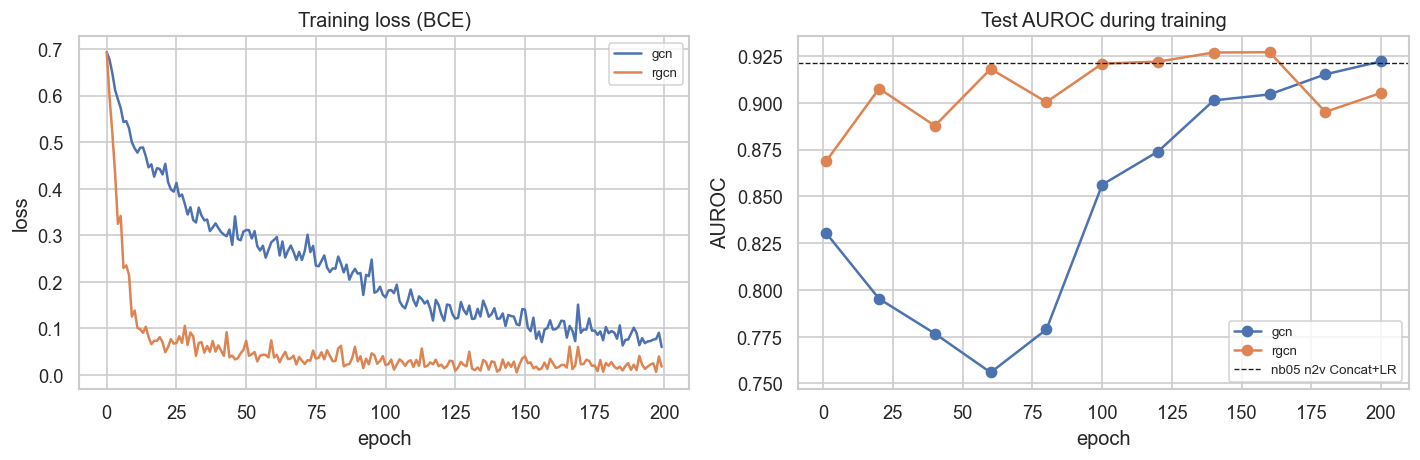

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, r in runs.items():
    axes[0].plot(r["losses"], label=name)
    ep, au = zip(*r["auroc_track"])
    axes[1].plot(ep, au, marker="o", label=name)
axes[0].set(title="Training loss (BCE)", xlabel="epoch", ylabel="loss"); axes[0].legend(fontsize=8)
axes[1].axhline(0.921, color="k", ls="--", lw=0.8, label="nb05 n2v Concat+LR")
axes[1].set(title="Test AUROC during training", xlabel="epoch", ylabel="AUROC")
axes[1].legend(fontsize=8)
plt.tight_layout()


## 6 · Evaluation

In [9]:
def bootstrap_ci(y_true, y_score, metric, B=500, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n)
        if y_true[idx].sum() == 0:
            vals[b] = np.nan; continue
        vals[b] = metric(y_true[idx], y_score[idx])
    vals = vals[~np.isnan(vals)]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


y_test = y[idx_test]
prior = float(y_test.mean())
K_LIST = [10, 50, 100, 500, 1000]

results = {}
for name, r in runs.items():
    st = r["scores"][idx_test]
    auroc = roc_auc_score(y_test, st)
    auprc = average_precision_score(y_test, st)
    lo_roc, hi_roc = bootstrap_ci(y_test, st, roc_auc_score)
    lo_pr,  hi_pr  = bootstrap_ci(y_test, st, average_precision_score)
    order = np.argsort(-st); yy = y_test[order]
    topk = {K: int(yy[:K].sum()) / K for K in K_LIST}
    results[name] = {"AUROC": auroc, "AUROC_ci": (lo_roc, hi_roc),
                     "AUPRC": auprc, "AUPRC_ci": (lo_pr, hi_pr), "top_k": topk}

n2v_meta = json.loads((ART / "predictions" / "node2vec_meta.json").read_text())
rows = [{"method": r["method"], "AUROC": round(r["AUROC"], 4), "AUPRC": round(r["AUPRC"], 4)}
        for r in n2v_meta["results"]]
for name, r in results.items():
    rows.append({"method": f"{name} · 2-layer (this nb)",
                 "AUROC": round(r["AUROC"], 4), "AUPRC": round(r["AUPRC"], 4)})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print()
for name, r in results.items():
    print(f"{name}: AUROC {r['AUROC']:.4f} [{r['AUROC_ci'][0]:.3f}, {r['AUROC_ci'][1]:.3f}]  "
          f"AUPRC {r['AUPRC']:.4f} [{r['AUPRC_ci'][0]:.4f}, {r['AUPRC_ci'][1]:.4f}]")


                        method  AUROC  AUPRC
      node2vec + Hadamard + LR 0.8594 0.0227
      node2vec + Concat   + LR 0.9209 0.0310
             node2vec + Cosine 0.7807 0.0176
spectral + Concat   + LR (nb4) 0.6811 0.0097
spectral + Cosine        (nb4) 0.6215 0.0058
       gcn · 2-layer (this nb) 0.9221 0.1792
      rgcn · 2-layer (this nb) 0.9052 0.1288

gcn: AUROC 0.9221 [0.894, 0.949]  AUPRC 0.1792 [0.1278, 0.2493]
rgcn: AUROC 0.9052 [0.882, 0.930]  AUPRC 0.1288 [0.0974, 0.1848]


In [10]:
print(f"Top-K precision (random baseline {prior:.4%})")
print(f"{'K':>6} " + "".join(f"{n:>14s}" for n in results) + f"{'winner':>10s}")
for K in K_LIST:
    vals = {n: results[n]["top_k"][K] for n in results}
    best = max(vals, key=vals.get)
    line = f"{K:>6} " + "".join(f"{vals[n]:>13.3f} " for n in results) + f"{best:>10s}"
    print(line)
print()
for name, r in runs.items():
    print(f"{name:5s}  {r['n_params']:>9,} params  {r['seconds']:>6.0f}s training")


Top-K precision (random baseline 0.3659%)
     K            gcn          rgcn    winner
    10         0.700         0.200        gcn
    50         0.420         0.300        gcn
   100         0.280         0.290       rgcn
   500         0.130         0.124        gcn
  1000         0.083         0.080        gcn

gcn    1,268,032 params     304s training
rgcn   1,333,728 params     427s training


## 7 · What the ablation says

Read the two GNNs against each other first, then both against nb05.

**GCN vs R-GCN** isolates edge-type awareness, since nothing else differs. Running both from the same seed state, as this notebook does, is what makes that isolation real — an earlier version of this experiment ran the two models in separate notebooks, where they consumed different amounts of randomness before training began.

That difference turned out to matter, and the way it mattered is itself a result. GCN reproduced almost exactly across the two setups (AUROC 0.922 both times, AUPRC 0.179 both times). R-GCN moved substantially: AUROC 0.917 → 0.899, AUPRC 0.184 → 0.135 (and this executed run landed at 0.905 / 0.129 — the drift across MPS re-runs is itself the point). Each run sits comfortably inside the other's bootstrap interval, so this is not a contradiction — it says **R-GCN's result is initialisation-sensitive in a way GCN's is not**, which is what you would expect from a model carrying three times the parameters on 604 positive edges.

On this seed R-GCN is clearly worse, and the temptation is to close the question here. But a claim about *stability* made from two runs is exactly the kind this project has been burned on before, so §8 runs both models across five seeds — and the five-seed answer revises this paragraph in one important place. Read it before quoting either model's AUPRC.

**GNN vs Node2Vec** isolates end-to-end supervision. Node2Vec optimises a Word2Vec objective that knows nothing about `treats`; the label only reaches it through a downstream logistic regression that cannot change the embedding. A GNN's gradient reaches every parameter, including the embedding table. Where the two differ most sharply is AUPRC and precision@K rather than AUROC — evidence that supervision buys sharpness at the top of the ranking rather than a uniformly better ordering.

## 8 · Multi-seed stability

§7 rests two claims on one seed each: GCN is stable where R-GCN is not, and R-GCN never wins. Five seeds per model settle both. The split never moves — it is locked to nb04 — so the seed controls only weight initialisation and which negatives are drawn each epoch. Seed 42 reuses the section-5 runs; the other four cost one training run each.

The comparison is paired: both models see the same seed, so the per-seed gap is free of seed-level noise.

In [11]:
SEEDS = [SEED, 43, 44, 45, 46]

ms_rows = []
for name in ("gcn", "rgcn"):
    for s in SEEDS:
        if s == SEED:
            scores = runs[name]["scores"]          # section 5 already trained this seed
        else:
            scores = train_model(name, log_every=EPOCHS, seed=s, verbose=False)["scores"]
        st = scores[idx_test]
        ms_rows.append({"model": name, "seed": s,
                        "AUROC": float(roc_auc_score(y_test, st)),
                        "AUPRC": float(average_precision_score(y_test, st))})
        print(f"  {name:5s} seed {s}: AUROC {ms_rows[-1]['AUROC']:.4f}  "
              f"AUPRC {ms_rows[-1]['AUPRC']:.4f}")

ms = pd.DataFrame(ms_rows)
print()
for name in ("gcn", "rgcn"):
    sub = ms[ms["model"] == name]
    print(f"{name:5s} AUROC {sub['AUROC'].mean():.4f} ± {sub['AUROC'].std():.4f} "
          f"(range {sub['AUROC'].min():.4f}-{sub['AUROC'].max():.4f}) | "
          f"AUPRC {sub['AUPRC'].mean():.4f} ± {sub['AUPRC'].std():.4f} "
          f"(range {sub['AUPRC'].min():.4f}-{sub['AUPRC'].max():.4f})")

gap = (ms[ms["model"] == "gcn"].set_index("seed")[["AUROC", "AUPRC"]]
       - ms[ms["model"] == "rgcn"].set_index("seed")[["AUROC", "AUPRC"]])
print("\nPaired per-seed gap (gcn - rgcn):")
print(gap.round(4).to_string())
print(f"\nAUPRC gap mean {gap['AUPRC'].mean():+.4f} ± {gap['AUPRC'].std():.4f}; "
      f"rgcn wins {int((gap['AUPRC'] < 0).sum())}/{len(gap)} seeds")

  gcn   seed 42: AUROC 0.9221  AUPRC 0.1792


  gcn   seed 43: AUROC 0.9139  AUPRC 0.1381


  gcn   seed 44: AUROC 0.9020  AUPRC 0.1059


  gcn   seed 45: AUROC 0.9285  AUPRC 0.1685


  gcn   seed 46: AUROC 0.9095  AUPRC 0.1239
  rgcn  seed 42: AUROC 0.9052  AUPRC 0.1288


  rgcn  seed 43: AUROC 0.9003  AUPRC 0.1559


  rgcn  seed 44: AUROC 0.9080  AUPRC 0.1314


  rgcn  seed 45: AUROC 0.8844  AUPRC 0.1583


  rgcn  seed 46: AUROC 0.8898  AUPRC 0.1302

gcn   AUROC 0.9152 ± 0.0104 (range 0.9020-0.9285) | AUPRC 0.1431 ± 0.0305 (range 0.1059-0.1792)
rgcn  AUROC 0.8976 ± 0.0101 (range 0.8844-0.9080) | AUPRC 0.1409 ± 0.0148 (range 0.1288-0.1583)

Paired per-seed gap (gcn - rgcn):
       AUROC   AUPRC
seed                
42    0.0169  0.0504
43    0.0136 -0.0178
44   -0.0061 -0.0256
45    0.0441  0.0103
46    0.0196 -0.0063

AUPRC gap mean +0.0022 ± 0.0301; rgcn wins 3/5 seeds


### What five seeds say

The single-seed story was wrong in an instructive way.

| | AUROC (mean ± std) | AUPRC (mean ± std) | AUPRC range |
|---|---|---|---|
| gcn | 0.9152 ± 0.0104 | 0.1431 ± 0.0305 | 0.106 – 0.179 |
| rgcn | 0.8976 ± 0.0101 | 0.1409 ± 0.0148 | 0.129 – 0.158 |

Three revisions to §7's reading:

1. **GCN's headline AUPRC 0.179 is the best of five seeds, not a typical run.** The mean is 0.143. Any comparison quoting 0.179 flatters GCN by a full standard deviation; the README now quotes both.
2. **"GCN stable, R-GCN not" inverts for AUPRC.** GCN's AUPRC spread (± 0.031) is twice R-GCN's (± 0.015). The earlier stability claim generalised from AUROC — where GCN genuinely is the steadier model — to a metric where it is not. Cross-notebook reproduction only ever checked one seed against itself.
3. **"R-GCN never beats GCN" survives only for AUROC** (paired gap +0.018, GCN wins 4/5 seeds). On AUPRC the paired gap is +0.002 ± 0.030 and R-GCN wins 3 seeds of 5 — a tie. The honest summary: GCN orders the whole pair universe better; at the top of the ranking, where AUPRC lives, the two are indistinguishable, and either one quoted on a single seed can be made to look like the winner.

What survives everything: R-GCN costs ~40 % more training time for no average gain on this graph, so the §7 conclusion stands — on CGD, relation awareness is not where the next gain lives. nb09 shows the same machinery *does* matter the moment the graph carries a relation whose meaning the task needs (`causes`). And the practical lesson for every later notebook: **single-seed AUPRC differences under ± 0.03 are seed noise on this task.**

## 9 · Persist

In [12]:
for name, r in runs.items():
    out = pairs[["compound", "disease", "y"]].copy()
    out[f"score_{name}"] = r["scores"]
    out["in_test"] = test_mask
    out.to_parquet(ART / "predictions" / f"{name}.parquet")

    res = results[name]
    meta_out = {
        "method": name,
        "library": f"torch {torch.__version__} + torch_geometric",
        "config": {
            "layers": 2, "hidden_dim": HIDDEN_DIM, "dropout": DROPOUT, "lr": LR,
            "epochs": EPOCHS, "neg_ratio": NEG_RATIO, "hub_K": HUB_K, "seed": SEED,
            "device": str(device), "relation_aware": name == "rgcn",
            "num_relations": int(num_relations) if name == "rgcn" else None,
            "num_bases": NUM_BASES if name == "rgcn" else None,
            "train_seconds": round(r["seconds"], 1),
            "n_params": int(r["n_params"]),
        },
        "walk_graph": {
            "kinds_kept": sorted(KEEP_KINDS), "n_nodes": int(num_nodes),
            "n_edges_directed": int(edge_index.size(1)),
            "test_ctd_edges_removed": int(dropped),
            "coverage": float(eval_have.float().mean()),
        },
        "results": {
            "AUROC": round(res["AUROC"], 4),
            "AUROC_95%": [round(res["AUROC_ci"][0], 4), round(res["AUROC_ci"][1], 4)],
            "AUPRC": round(res["AUPRC"], 4),
            "AUPRC_95%": [round(res["AUPRC_ci"][0], 4), round(res["AUPRC_ci"][1], 4)],
            "top_k": {str(K): round(v, 4) for K, v in res["top_k"].items()},
            "lift_vs_random": {str(K): round(v / prior, 1) for K, v in res["top_k"].items()},
        },
        "training_curve": {"loss_last10": [round(x, 4) for x in r["losses"][-10:]],
                           "auroc_history": [(e, round(a, 4)) for e, a in r["auroc_track"]]},
        "multiseed": ms.loc[ms["model"] == name, ["seed", "AUROC", "AUPRC"]]
                       .round(4).to_dict(orient="records"),
        "compared_with": {x["method"]: x["AUROC"] for x in n2v_meta["results"]},
    }
    (ART / "predictions" / f"{name}_meta.json").write_text(json.dumps(meta_out, indent=2, default=str))
    print(f"Wrote artifacts/predictions/{name}.parquet + {name}_meta.json")


Wrote artifacts/predictions/gcn.parquet + gcn_meta.json
Wrote artifacts/predictions/rgcn.parquet + rgcn_meta.json


## 10 · Next

nb10 folds both models into the ensemble alongside the walk-based methods. nb11 takes the stronger of the two outside the graph entirely, checking its top-ranked `y = 0` pairs against clinical trial registrations. nb12 then revisits the one component both models share — the uniform negative sampler — and adopts a 25 % hard-negative mix as the project default, with a seed-stability section mirroring §8.